# High-Accuracy Emotion Modeling
This notebook is designed to give a much stronger setup than the baseline CNNs and improve your chances of reaching the best accuracy your dataset can support.

In [1]:
import sys
!{sys.executable} -m pip install torch torchvision matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
import torch

from emotion_modeling_utils import (
    build_resnet18_transfer_model,
    build_weighted_loss,
    evaluate_model,
    get_device,
    predict_with_confidence,
    prepare_transfer_dataloaders,
    seed_everything,
    train_model,
    unfreeze_resnet_stage3_and_4,
)

seed_everything(42)
device = get_device()
print("Using device:", device)

Using device: mps


In [3]:
data = prepare_transfer_dataloaders(
    train_dir="archive/train",
    test_dir="archive/test",
    batch_size=64,
    val_ratio=0.2,
    image_size=224,
    seed=42,
)

train_loader = data["train_loader"]
val_loader = data["val_loader"]
test_loader = data["test_loader"]
class_weights = data["class_weights"]
idx_to_class = data["idx_to_class"]
num_classes = data["num_classes"]

print("Train size:", data["train_size"])
print("Validation size:", data["val_size"])
print("Class counts:", data["class_counts"])
print("Class weights:", class_weights)

Train size: 22967
Validation size: 5742
Class counts: Counter({3: 7215, 4: 4965, 5: 4830, 2: 4097, 0: 3995, 6: 3171, 1: 436})
Class weights: tensor([ 7.1862, 65.8463,  7.0073,  3.9791,  5.7823,  5.9439,  9.0536])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3785625].


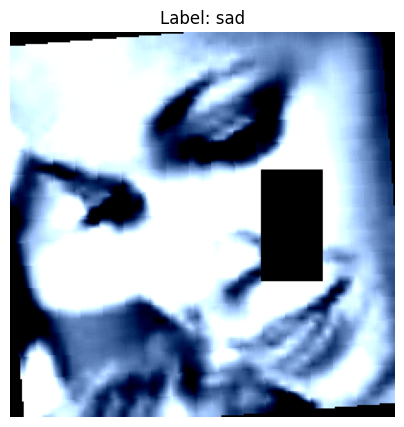

In [4]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(5, 5))
plt.imshow(images[0].permute(1, 2, 0).cpu())
plt.title(f"Label: {idx_to_class[labels[0].item()]}")
plt.axis("off")
plt.show()

## Stage 1: Train a New Classification Head

We start with a pretrained `ResNet18`, freeze the backbone, and train only the classifier head.

In [5]:
transfer_model, loaded_pretrained = build_resnet18_transfer_model(
    num_classes=num_classes,
    pretrained=True,
    freeze_backbone=True,
    local_weights_path="model_weights/resnet18-f37072fd.pth",
)
transfer_model = transfer_model.to(device)
print("Loaded pretrained weights:", loaded_pretrained)
if not loaded_pretrained:
    raise RuntimeError("Pretrained ResNet18 weights were not loaded. Stop here and fix the weights path before training.")

stage1_criterion = build_weighted_loss(class_weights, device, label_smoothing=0.05)
stage1_optimizer = torch.optim.AdamW(
    transfer_model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)
stage1_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    stage1_optimizer,
    mode="min",
    factor=0.5,
    patience=2,
)

stage1_history = train_model(
    transfer_model,
    train_loader,
    val_loader,
    stage1_criterion,
    stage1_optimizer,
    device=device,
    epochs=5,
    scheduler=stage1_scheduler,
    patience=4,
)

print("Stage 1 best val accuracy:", stage1_history["best_val_acc"])
print("Stage 1 best epoch:", stage1_history["best_epoch"])

Loaded pretrained weights from local file: model_weights/resnet18-f37072fd.pth
Loaded pretrained weights: True


KeyboardInterrupt: 

## Stage 2: Fine-Tune the Top Backbone Layer

After the head is trained, unfreeze `layer4` and continue with a smaller learning rate.

In [ ]:
unfreeze_resnet_stage3_and_4(transfer_model)

stage2_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, transfer_model.parameters()),
    lr=1e-4,
    weight_decay=1e-4,
)
stage2_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    stage2_optimizer,
    mode="min",
    factor=0.5,
    patience=2,
)

stage2_history = train_model(
    transfer_model,
    train_loader,
    val_loader,
    stage1_criterion,
    stage2_optimizer,
    device=device,
    epochs=15,
    scheduler=stage2_scheduler,
    patience=6,
)

print("Stage 2 best val accuracy:", stage2_history["best_val_acc"])
print("Stage 2 best epoch:", stage2_history["best_epoch"])

Epoch 1/12 | Train Loss: 2.0493 | Train Acc: 0.1510 | Val Loss: 2.0183 | Val Acc: 0.1217 | LR: 0.000100
Epoch 2/12 | Train Loss: 1.9920 | Train Acc: 0.2006 | Val Loss: 1.9568 | Val Acc: 0.1778 | LR: 0.000100
Epoch 3/12 | Train Loss: 1.9165 | Train Acc: 0.2730 | Val Loss: 1.8863 | Val Acc: 0.3340 | LR: 0.000100
Epoch 4/12 | Train Loss: 1.8774 | Train Acc: 0.2980 | Val Loss: 1.8499 | Val Acc: 0.3779 | LR: 0.000100
Epoch 5/12 | Train Loss: 1.8277 | Train Acc: 0.3276 | Val Loss: 1.8246 | Val Acc: 0.2802 | LR: 0.000100
Epoch 6/12 | Train Loss: 1.7980 | Train Acc: 0.3439 | Val Loss: 1.8364 | Val Acc: 0.2719 | LR: 0.000100
Epoch 7/12 | Train Loss: 1.7649 | Train Acc: 0.3629 | Val Loss: 1.8410 | Val Acc: 0.3096 | LR: 0.000100
Epoch 8/12 | Train Loss: 1.7346 | Train Acc: 0.3749 | Val Loss: 1.7854 | Val Acc: 0.3922 | LR: 0.000100
Epoch 9/12 | Train Loss: 1.7106 | Train Acc: 0.3907 | Val Loss: 1.8045 | Val Acc: 0.2759 | LR: 0.000100
Epoch 10/12 | Train Loss: 1.6938 | Train Acc: 0.3942 | Val Loss:

In [ ]:
test_loss, test_acc = evaluate_model(transfer_model, test_loader, stage1_criterion, device)
print(f"Transfer Model Test Loss: {test_loss:.4f}")
print(f"Transfer Model Test Accuracy: {test_acc:.4f}")

Transfer Model Test Loss: 1.8121
Transfer Model Test Accuracy: 0.4115


In [ ]:
sample_images, _ = next(iter(test_loader))
sample_images = sample_images.to(device)

transfer_model.eval()
with torch.no_grad():
    outputs = transfer_model(sample_images)
    probs = torch.softmax(outputs, dim=1)

print("Probability tensor shape:", probs.shape)
print("First sample probabilities:", probs[0])
predict_with_confidence(transfer_model, test_loader, idx_to_class, device=device, max_examples=5)

Probability tensor shape: torch.Size([64, 7])
First sample probabilities: tensor([0.1610, 0.1227, 0.0561, 0.4280, 0.1222, 0.0751, 0.0349])
True: angry | Predicted: happy | Confidence: 0.4280
True: angry | Predicted: angry | Confidence: 0.2805
True: angry | Predicted: sad | Confidence: 0.2964
True: angry | Predicted: angry | Confidence: 0.2455
True: angry | Predicted: angry | Confidence: 0.4654


tensor([[0.1610, 0.1227, 0.0561, 0.4280, 0.1222, 0.0751, 0.0349],
        [0.2805, 0.0758, 0.1401, 0.1001, 0.1057, 0.1108, 0.1871],
        [0.1667, 0.0681, 0.0916, 0.1817, 0.1338, 0.2964, 0.0617],
        [0.2455, 0.0201, 0.1005, 0.0591, 0.2179, 0.1689, 0.1879],
        [0.4654, 0.1192, 0.0572, 0.0442, 0.0788, 0.2159, 0.0192],
        [0.0800, 0.1213, 0.1857, 0.1108, 0.1593, 0.1355, 0.2074],
        [0.2488, 0.3368, 0.0476, 0.1115, 0.1212, 0.0665, 0.0675],
        [0.3743, 0.1188, 0.0905, 0.1385, 0.0797, 0.1471, 0.0512],
        [0.2527, 0.0667, 0.1313, 0.0853, 0.1349, 0.2535, 0.0756],
        [0.4937, 0.2560, 0.0706, 0.0347, 0.0265, 0.0760, 0.0425],
        [0.0797, 0.2053, 0.1180, 0.0797, 0.0593, 0.0389, 0.4193],
        [0.0661, 0.2987, 0.0338, 0.3164, 0.2009, 0.0406, 0.0435],
        [0.3255, 0.1681, 0.0582, 0.0285, 0.2240, 0.1814, 0.0143],
        [0.1187, 0.1521, 0.0541, 0.0124, 0.4069, 0.2313, 0.0245],
        [0.0385, 0.1323, 0.0778, 0.1672, 0.1904, 0.0700, 0.3239],
        [0